In [1]:
# --- Importações Essenciais ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)
pd.set_option('display.max_columns', 50)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# --- Definição dos Caminhos ---

# O caminho relativo do notebook para a pasta de dados brutos
data_path = '../../data/raw/BETH'

# Nomes dos arquivos
train_filename = 'labelled_training_data.csv'
val_filename = 'labelled_validation_data.csv'
test_filename = 'labelled_testing_data.csv'

# Caminhos completos
train_path = os.path.join(data_path, train_filename)
val_path = os.path.join(data_path, val_filename)
test_path = os.path.join(data_path, test_filename)

# --- Carregamento dos Dados ---
try:
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)
    
    print("Datasets carregados com sucesso!")
    print(f"Treino:      {train_df.shape[0]:>7} linhas, {train_df.shape[1]} colunas")
    print(f"Validação:   {val_df.shape[0]:>7} linhas, {val_df.shape[1]} colunas")
    print(f"Teste:       {test_df.shape[0]:>7} linhas, {test_df.shape[1]} colunas")

except FileNotFoundError:
    print("Erro: Arquivos do dataset não encontrados.")
    print(f"Verifique se os arquivos estão no diretório: {os.path.abspath(data_path)}")

Datasets carregados com sucesso!
Treino:       763144 linhas, 16 colunas
Validação:    188967 linhas, 16 colunas
Teste:        188967 linhas, 16 colunas


In [3]:
# FASE 1: Análise Geral e Limpeza Inicial

# 1. Visualizar as primeiras linhas do conjunto de treino
print("--- Primeiras 5 linhas do dataset de Treino ---")
print(train_df.head())

# 2. Verificar os tipos de dados e valores nulos
print("\n--- Informações do DataFrame de Treino ---")
train_df.info()

# 3. Análise estatística das colunas numéricas
print("\n--- Estatísticas Descritivas (Treino) ---")
print(train_df.describe())

# 4. Verificar a cardinalidade das features categóricas
print("\n--- Cardinalidade (Valores Únicos) no Treino ---")
print(train_df.select_dtypes(include=['object', 'category']).nunique())

--- Primeiras 5 linhas do dataset de Treino ---
     timestamp  processId  threadId  parentProcessId  userId  mountNamespace  \
0  1809.495787        381      7337                1     100      4026532231   
1  1809.495832        381      7337                1     100      4026532231   
2  1809.495921        381      7337                1     100      4026532231   
3  1894.139651       7347      7347             7341       0      4026531840   
4  1894.142127       7347      7347             7341       0      4026531840   

  processName         hostName  eventId           eventName  \
0       close  ip-10-100-1-120      157               prctl   
1       close  ip-10-100-1-120        3               close   
2       close  ip-10-100-1-120     1010  sched_process_exit   
3          sh  ip-10-100-1-120       21              access   
4          sh  ip-10-100-1-120     1005  security_file_open   

                         stackAddresses  argsNum  returnValue  \
0  [140662171848350, 116498

--- Análise da Variável Alvo no Conjunto de Teste ---
Distribuição da variável alvo 'out' (%):
out
1    83.841094
0    16.158906
Name: proportion, dtype: float64


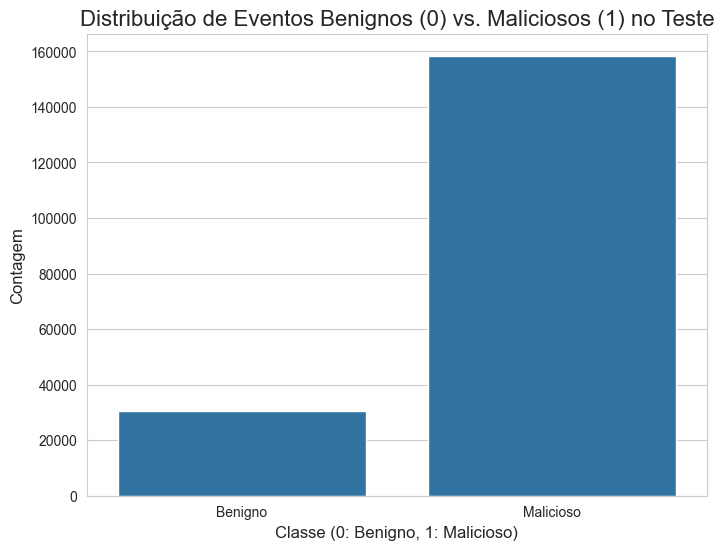


--- Contagem de eventos maliciosos por Host (no Teste) ---
hostName
ip-10-100-1-217    158432
Name: out, dtype: int64


In [4]:
# FASE 2: Análise da Variável Alvo

# A variável alvo 'out' (malicioso/benigno) só existe no conjunto de teste.
# As colunas 'sus' e 'evil' indicam isso. Vamos usar 'evil' como nosso alvo 'out'.
print("--- Análise da Variável Alvo no Conjunto de Teste ---")

# Criar a coluna alvo 'out'
test_df['out'] = test_df['evil']

# Verificar a distribuição e o desbalanceamento
target_distribution = test_df['out'].value_counts(normalize=True) * 100
print("Distribuição da variável alvo 'out' (%):")
print(target_distribution)

# Visualizar a distribuição
plt.figure(figsize=(8, 6))
sns.countplot(x='out', data=test_df)
plt.title('Distribuição de Eventos Benignos (0) vs. Maliciosos (1) no Teste', fontsize=16)
plt.xlabel('Classe (0: Benigno, 1: Malicioso)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks([0, 1], ['Benigno', 'Malicioso'])
plt.show()

# Verificar se os ataques estão concentrados em hosts específicos
print("\n--- Contagem de eventos maliciosos por Host (no Teste) ---")
print(test_df.groupby('hostName')['out'].sum().sort_values(ascending=False))

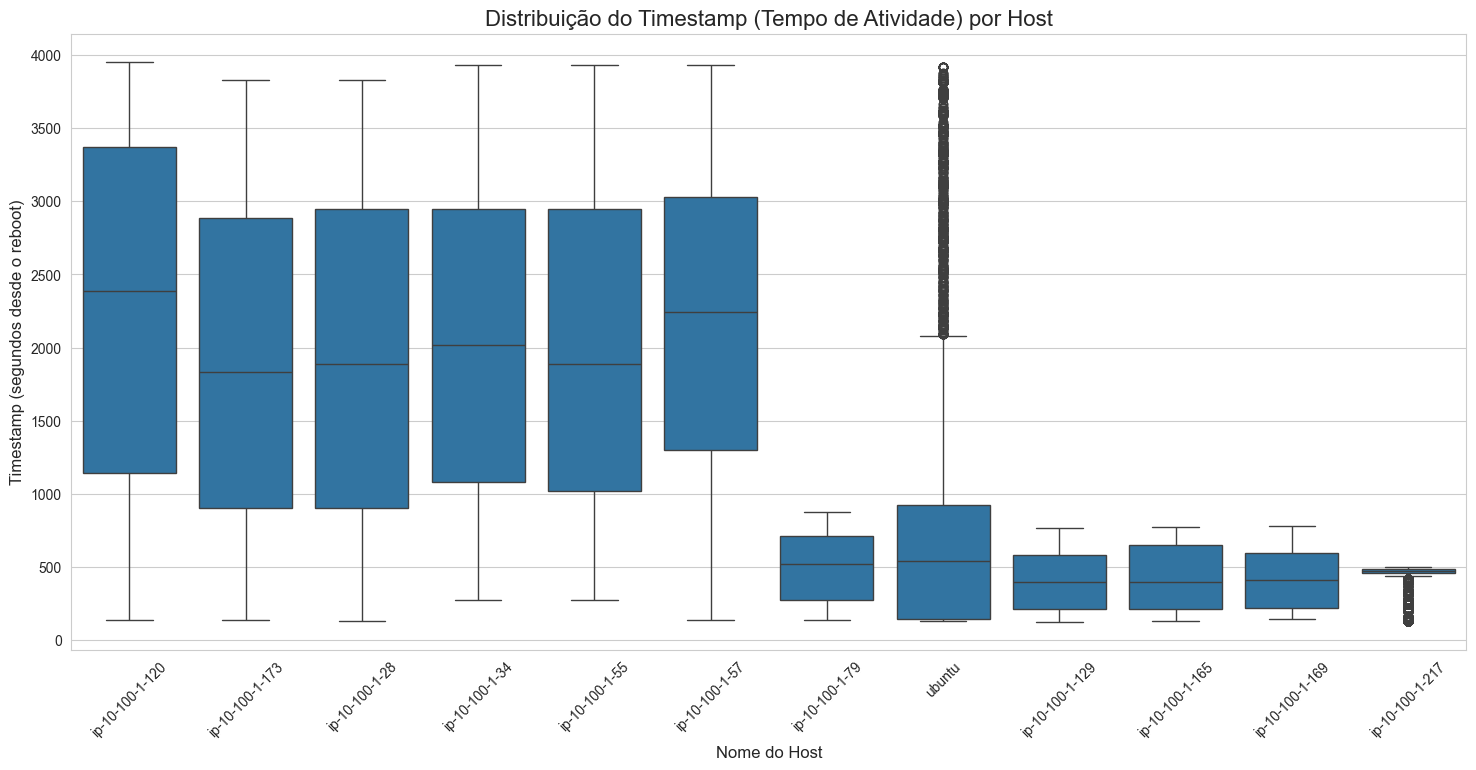

In [5]:
# Análise do 'timestamp' (tempo desde o reboot) por host

# Para ter uma visão completa, vamos concatenar os dados dos 3 conjuntos
combined_df_for_ts = pd.concat([
    train_df[['timestamp', 'hostName']],
    val_df[['timestamp', 'hostName']],
    test_df[['timestamp', 'hostName']]
], ignore_index=True)

# Plotar a distribuição do tempo de atividade para cada host
plt.figure(figsize=(18, 8))
sns.boxplot(x='hostName', y='timestamp', data=combined_df_for_ts)
plt.title('Distribuição do Timestamp (Tempo de Atividade) por Host', fontsize=16)
plt.xlabel('Nome do Host', fontsize=12)
plt.ylabel('Timestamp (segundos desde o reboot)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

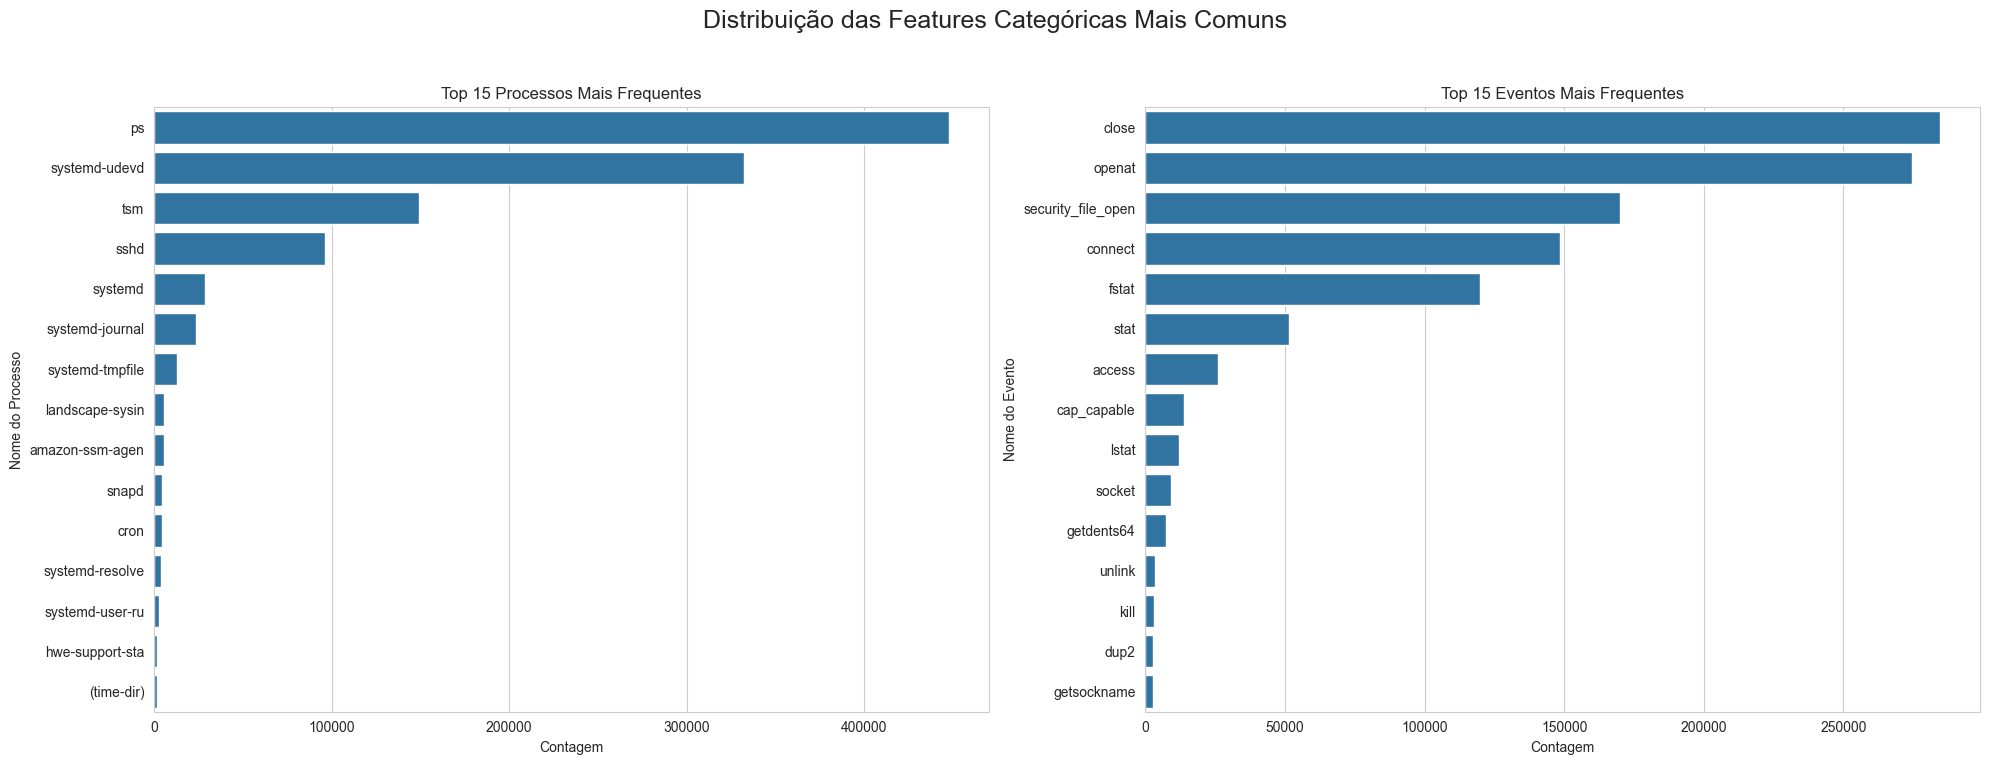


--- Análise de 'mountNamespace' ---
Total de valores únicos: 6
Distribuição dos 5 valores mais comuns:
mountNamespace
4026531840    0.702088
4026532217    0.291305
4026532232    0.003276
4026532229    0.001222
4026532231    0.001073
Name: proportion, dtype: float64


In [6]:
# Análise das features categóricas com categorias dominantes

# Combinar todos os dados para uma visão global
combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Distribuição das Features Categóricas Mais Comuns', fontsize=18)

# Gráfico para 'processName'
sns.countplot(y='processName', data=combined_df, order=combined_df['processName'].value_counts().iloc[:15].index, ax=axes[0])
axes[0].set_title('Top 15 Processos Mais Frequentes')
axes[0].set_xlabel('Contagem')
axes[0].set_ylabel('Nome do Processo')

# Gráfico para 'eventName'
sns.countplot(y='eventName', data=combined_df, order=combined_df['eventName'].value_counts().iloc[:15].index, ax=axes[1])
axes[1].set_title('Top 15 Eventos Mais Frequentes')
axes[1].set_xlabel('Contagem')
axes[1].set_ylabel('Nome do Evento')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Investigar a variância de 'mountNamespace'
print(f"\n--- Análise de 'mountNamespace' ---")
print(f"Total de valores únicos: {combined_df['mountNamespace'].nunique()}")
print("Distribuição dos 5 valores mais comuns:")
print(combined_df['mountNamespace'].value_counts(normalize=True).head())

--- Análise Bivariada (Features vs. Alvo no Teste) ---


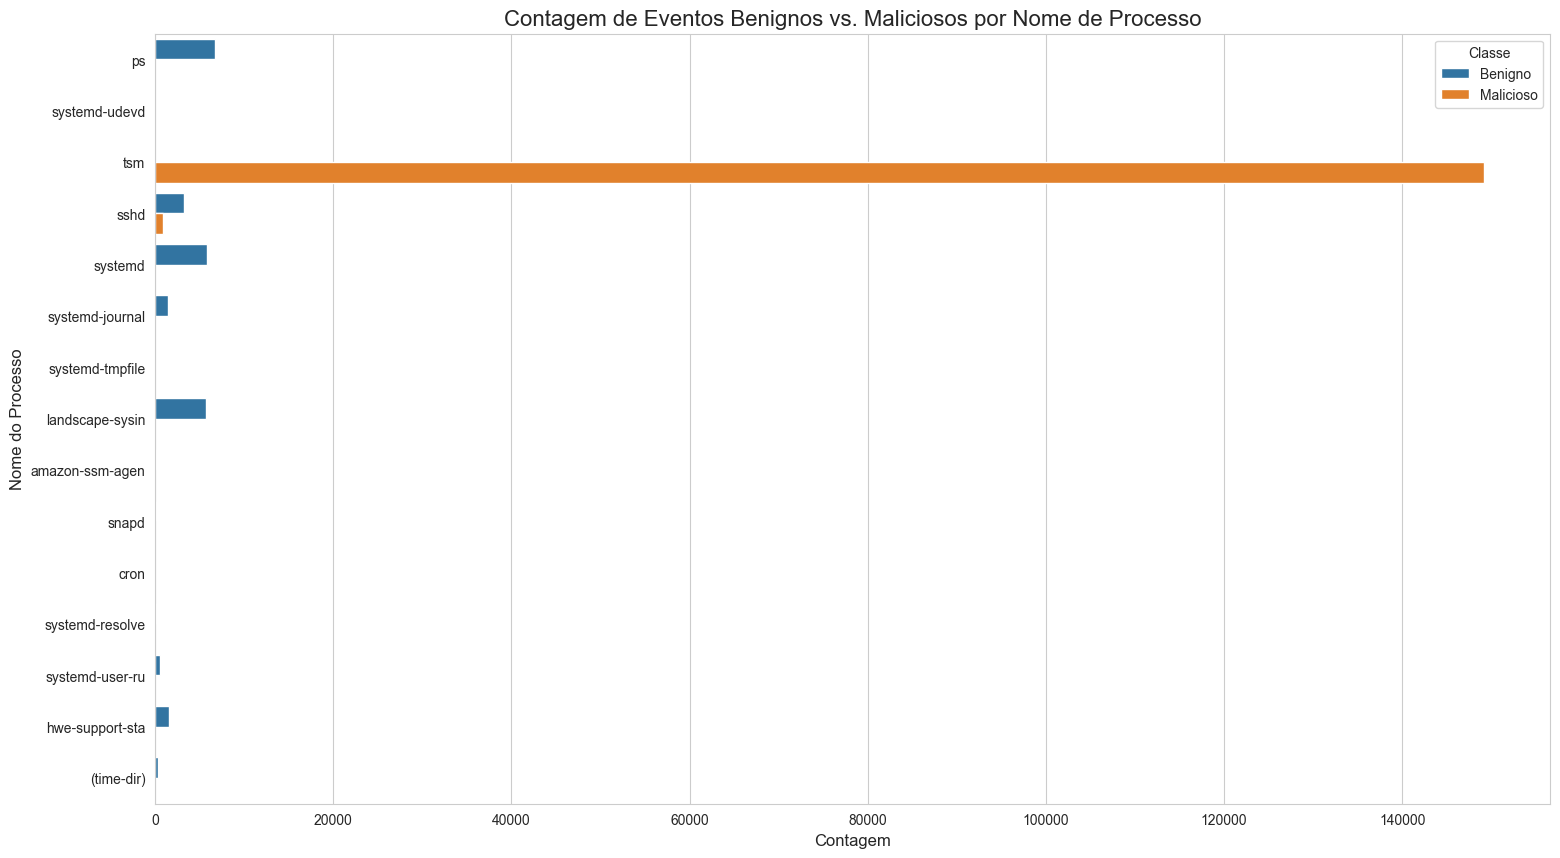

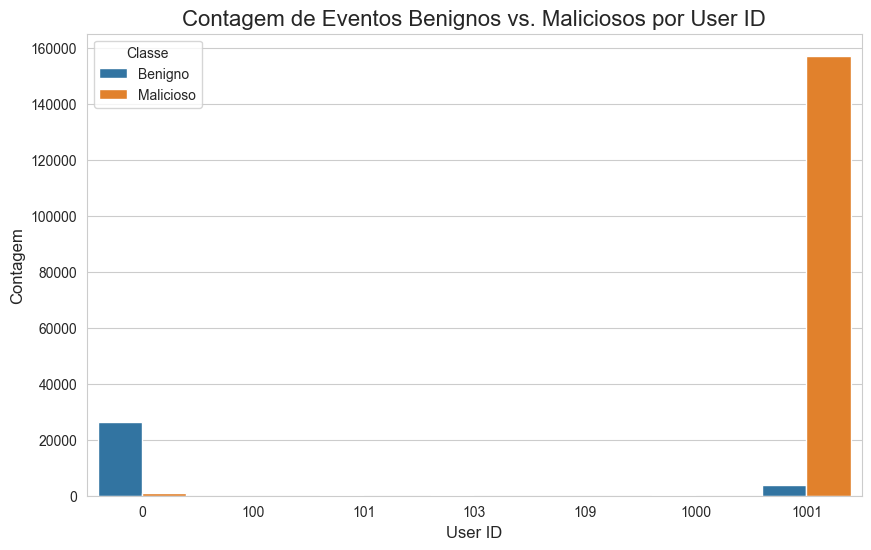

In [7]:
# FASE 4: Relação entre Features e o Alvo (no Conjunto de Teste)

print("--- Análise Bivariada (Features vs. Alvo no Teste) ---")

# Filtrar para os 15 processos mais comuns no geral para uma visualização mais limpa
top_15_processes = combined_df['processName'].value_counts().iloc[:15].index
test_df_filtered = test_df[test_df['processName'].isin(top_15_processes)]

# Gráfico: processName vs. out
plt.figure(figsize=(18, 10))
sns.countplot(y='processName', hue='out', data=test_df_filtered, order=top_15_processes)
plt.title('Contagem de Eventos Benignos vs. Maliciosos por Nome de Processo', fontsize=16)
plt.xlabel('Contagem', fontsize=12)
plt.ylabel('Nome do Processo', fontsize=12)
plt.legend(title='Classe', labels=['Benigno', 'Malicioso'])
plt.show()

# Gráfico: userId vs. out
plt.figure(figsize=(10, 6))
sns.countplot(x='userId', hue='out', data=test_df)
plt.title('Contagem de Eventos Benignos vs. Maliciosos por User ID', fontsize=16)
plt.xlabel('User ID', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.legend(title='Classe', labels=['Benigno', 'Malicioso'])
plt.show()